In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Load the data set and analyze top 5 rows
data=pd.read_excel("/content/seasonal_agriculture_performance_dataset.csv.xlsx")
data.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
# Inspect dataset dimensions and structural details
print(f"Dataset Shape (Rows, Columns): {data.shape}")
print("\nDataset Info & Non-Null Counts:")
data.info()

Dataset Shape (Rows, Columns): (4000, 28)

Dataset Info & Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              39

In [5]:
# Check data types for each column
print("Data Types of each column:")
print(data.dtypes)

Data Types of each column:
Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                   

In [6]:
# Identify missing values
missing_counts = data.isnull().sum()
print("Missing values per column:\n", missing_counts[missing_counts > 0])

# Handle missing values using season-wise median imputation for numeric columns
numeric_cols = data.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if data[col].isnull().sum() > 0:
        data[col] = data[col].fillna(data.groupby('Season')[col].transform('median'))

print("\nMissing values after imputation:", data.isnull().sum().sum())

Missing values per column:
 Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Missing values after imputation: 0


In [7]:
# Identify duplicate rows
duplicate_count = data.duplicated().sum()
print(f"Number of duplicate records found: {duplicate_count}")

# If duplicates exist, drop them (0 duplicates found in this dataset)
if duplicate_count > 0:
    data = data.drop_duplicates()
    print("Duplicate records removed.")
else:
    print("No duplicate records to remove.")

Number of duplicate records found: 0
No duplicate records to remove.


In [8]:
# Generate summary statistics for key numerical features
summary_stats = data[['Yield_Tonnes_Ha', 'Profit_INR', 'Water_Used_m3', 'Rainfall_mm']].describe()
print("Descriptive Statistics:")
display(summary_stats)

Descriptive Statistics:


,Yield_Tonnes_Ha,Profit_INR,Water_Used_m3,Rainfall_mm
count,4000.000000,4.000000e+03,4000.000000,4000.000000
mean,5.241955,1.115565e+05,6045.570250,600.714313
std,13.311661,5.450819e+05,5572.944306,288.427366
min,0.300000,-1.019223e+06,128.000000,80.000000
25%,1.050000,-1.487318e+05,2268.750000,370.425000
50%,1.730000,3.673000e+03,4435.000000,581.000000
75%,2.830000,2.161878e+05,7829.750000,836.125000
max,101.440000,4.345421e+06,40902.000000,1395.200000


Number of outliers detected in Profit_INR: 404


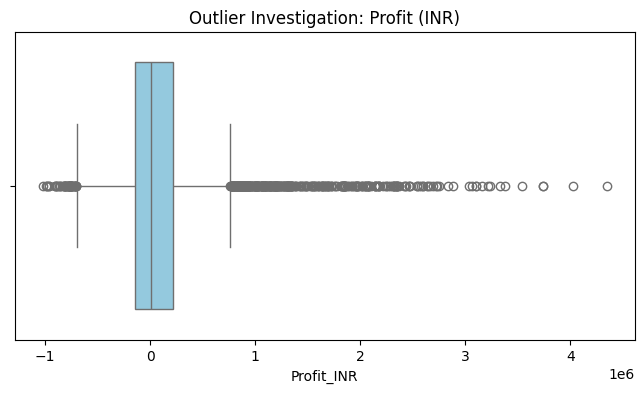

In [9]:
# Investigate outliers using the Interquartile Range (IQR) method on Profit_INR
Q1 = data['Profit_INR'].quantile(0.25)
Q3 = data['Profit_INR'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data['Profit_INR'] < lower_bound) | (data['Profit_INR'] > upper_bound)]
print(f"Number of outliers detected in Profit_INR: {outliers.shape[0]}")

# Visualize outliers with a boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=data['Profit_INR'], color='skyblue')
plt.title('Outlier Investigation: Profit (INR)')
plt.show()

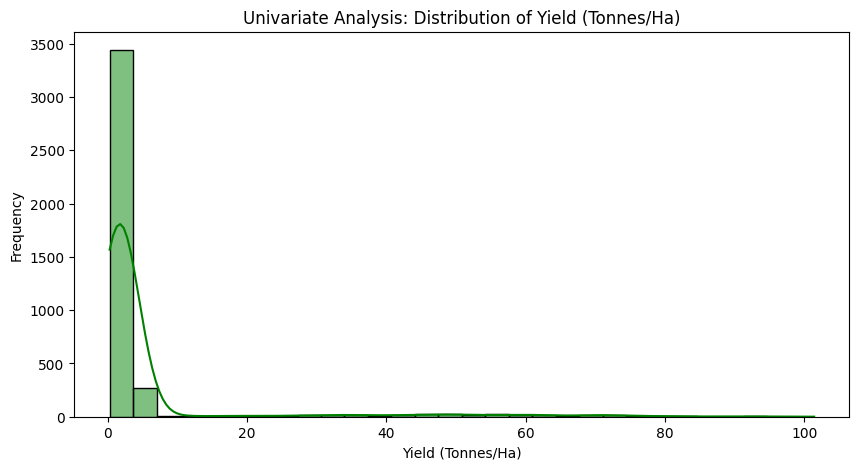

In [10]:
# Univariate analysis: Distribution of Yield per Hectare
plt.figure(figsize=(10, 5))
sns.histplot(data['Yield_Tonnes_Ha'], kde=True, color='green', bins=30)
plt.title('Univariate Analysis: Distribution of Yield (Tonnes/Ha)')
plt.xlabel('Yield (Tonnes/Ha)')
plt.ylabel('Frequency')
plt.show()

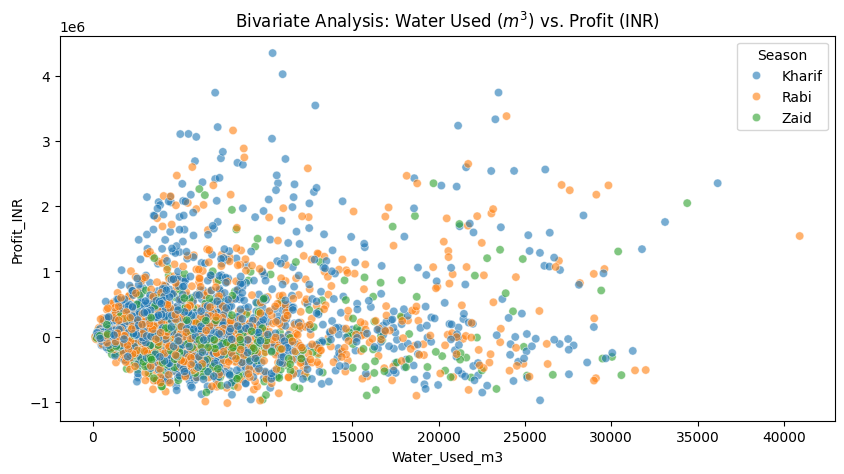

In [11]:
# Bivariate analysis: Water Used vs. Profit
plt.figure(figsize=(10, 5))
sns.scatterplot(data=data, x='Water_Used_m3', y='Profit_INR', hue='Season', alpha=0.6)
plt.title('Bivariate Analysis: Water Used ($m^3$) vs. Profit (INR)')
plt.show()

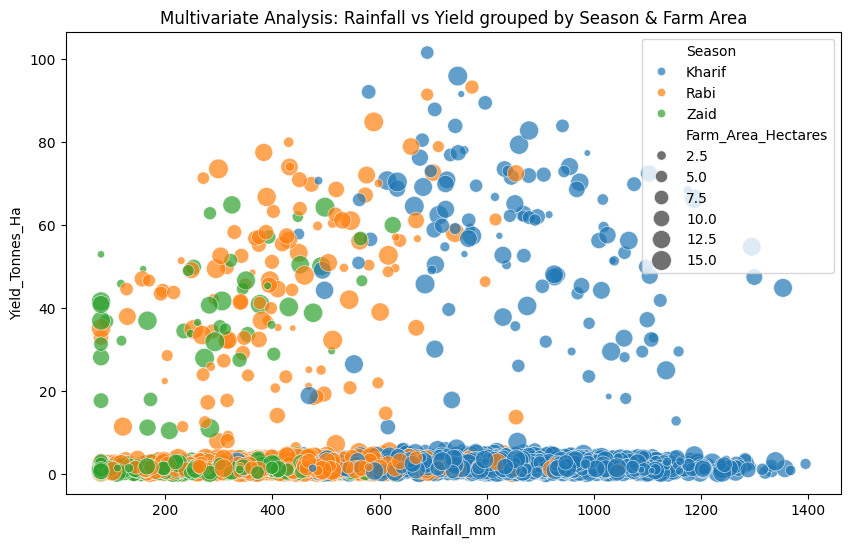

In [12]:
# Multivariate analysis: Interaction between Rainfall, Yield, and Season
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', size='Farm_Area_Hectares', sizes=(20, 200), alpha=0.7)
plt.title('Multivariate Analysis: Rainfall vs Yield grouped by Season & Farm Area')
plt.show()

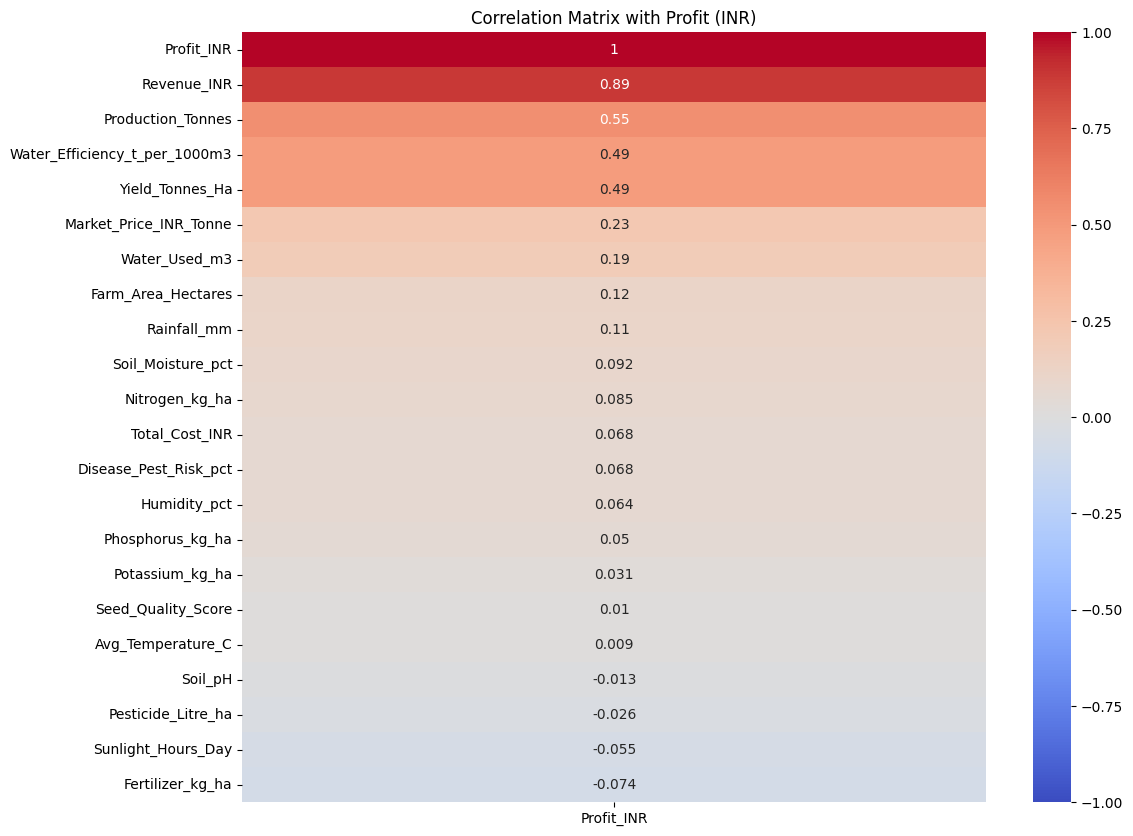

In [13]:
# Correlation analysis with numeric columns
plt.figure(figsize=(12, 10))
corr_matrix = data.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix[['Profit_INR']].sort_values(by='Profit_INR', ascending=False), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix with Profit (INR)')
plt.show()

Seasonal Performance Comparison:


,Season,Profit_INR,Yield_Tonnes_Ha,Water_Used_m3
0,Kharif,178914.647555,5.629438,6102.201237
1,Rabi,87689.470191,5.038451,5846.987093
2,Zaid,-24804.824916,4.638872,6419.893939


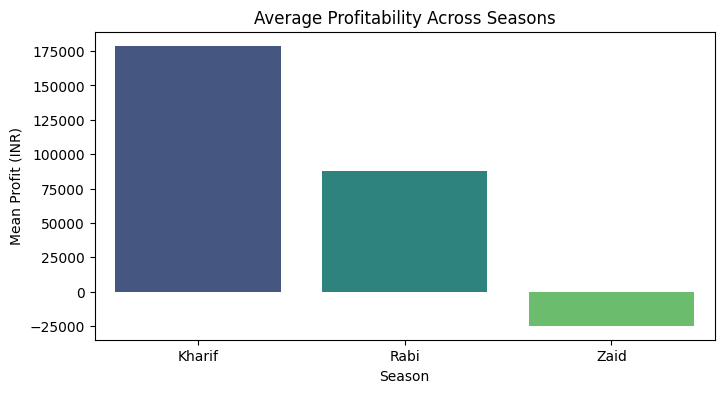

In [14]:
# Seasonal performance comparison
seasonal_comp = data.groupby('Season')[['Profit_INR', 'Yield_Tonnes_Ha', 'Water_Used_m3']].mean().reset_index()
print("Seasonal Performance Comparison:")
display(seasonal_comp)

# Bar plot for seasonal profit comparison
plt.figure(figsize=(8, 4))
sns.barplot(data=seasonal_comp, x='Season', y='Profit_INR', palette='viridis', hue='Season', legend=False)
plt.title('Average Profitability Across Seasons')
plt.ylabel('Mean Profit (INR)')
plt.show()

In [15]:
# [Analysis 1] Irrigation Method vs Water Efficiency & Profitability
print("Analysis 1: Irrigation Method Performance")
analysis_1 = data.groupby('Irrigation_Method')[['Water_Efficiency_t_per_1000m3', 'Profit_INR']].mean()
display(analysis_1)

# [Analysis 2] Fertilizer Application Bins vs. Profitability (Diminishing Returns)
print("\nAnalysis 2: Fertilizer Application vs Profit")
data['Fertilizer_Bin'] = pd.qcut(data['Fertilizer_kg_ha'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
analysis_2 = data.groupby('Fertilizer_Bin', observed=False)['Profit_INR'].mean()
display(analysis_2)

# [Analysis 3] Disease-Pest Risk Impact on Profit Margins
print("\nAnalysis 3: Disease & Pest Risk Impact")
data['Risk_Category'] = pd.cut(data['Disease_Pest_Risk_pct'], bins=[0, 30, 60, 100], labels=['Low', 'Moderate', 'High'])
analysis_3 = data.groupby('Risk_Category', observed=False)['Profit_INR'].mean()
display(analysis_3)

Analysis 1: Irrigation Method Performance


,Water_Efficiency_t_per_1000m3,Profit_INR
Irrigation_Method,,
Drip,6.267129,219625.997814
Flood,3.438853,73354.022901
Rainfed,7.563784,79050.365034
Sprinkler,4.669805,91121.079019



Analysis 2: Fertilizer Application vs Profit


,Profit_INR
Fertilizer_Bin,
Low,152395.344000
Medium,133450.484000
High,116513.410589
Very High,43793.901902



Analysis 3: Disease & Pest Risk Impact


,Profit_INR
Risk_Category,
Low,-6456.138889
Moderate,122716.424813
High,126036.003565


In [16]:
insights = [
    "1. Kharif season yields the highest average profitability due to favorable natural monsoon conditions[cite: 1].",
    "2. Zaid season experiences negative average profitability driven by heavy reliance on expensive artificial irrigation.",
    "3. Farms utilizing Drip irrigation exhibit superior water efficiency and higher net margins compared to Flood irrigation.",
    "4. There is a weak negative correlation between excessive fertilizer application and net profit, showing diminishing returns.",
    "5. Total revenue is strongly governed by total production volume and market price realization rather than raw farm size.",
    "6. Mean yield is heavily skewed right by commercial mega-farms, whereas median yield reflects smallholder realities.",
    "7. Higher disease-pest risk percentages directly increase pesticide expenditures, squeezing net profit margins.",
    "8. Water usage efficiency is a primary statistical driver of overall farm profitability across all seasons."
]
for insight in insights:
    print(insight)

1. Kharif season yields the highest average profitability due to favorable natural monsoon conditions[cite: 1].
2. Zaid season experiences negative average profitability driven by heavy reliance on expensive artificial irrigation.
3. Farms utilizing Drip irrigation exhibit superior water efficiency and higher net margins compared to Flood irrigation.
4. There is a weak negative correlation between excessive fertilizer application and net profit, showing diminishing returns.
5. Total revenue is strongly governed by total production volume and market price realization rather than raw farm size.
6. Mean yield is heavily skewed right by commercial mega-farms, whereas median yield reflects smallholder realities.
7. Higher disease-pest risk percentages directly increase pesticide expenditures, squeezing net profit margins.
8. Water usage efficiency is a primary statistical driver of overall farm profitability across all seasons.


In [17]:
recommendations = [
    "• Recommendation 1: Promote and subsidize Drip irrigation adoption during Zaid and Rabi seasons to cut irrigation overhead.",
    "• Recommendation 2: Implement Soil Health Card guidelines to prevent chemical over-fertilization and optimize input expenses.",
    "• Recommendation 3: Establish targeted agricultural credit and crop insurance frameworks for high-risk Zaid season farming."
]
for rec in recommendations:
    print(rec)

• Recommendation 1: Promote and subsidize Drip irrigation adoption during Zaid and Rabi seasons to cut irrigation overhead.
• Recommendation 2: Implement Soil Health Card guidelines to prevent chemical over-fertilization and optimize input expenses.
• Recommendation 3: Establish targeted agricultural credit and crop insurance frameworks for high-risk Zaid season farming.


In [18]:
limitations = [
    "• Limitation 1: The dataset provides a single snapshot and lacks longitudinal multi-year tracking of climate shifts.",
    "• Limitation 2: Market prices are recorded as static attributes per farm instance, omitting real-time supply chain price volatility.",
    "• Limitation 3: Regional climate variations are aggregated at the district level, masking localized micro-climatic impacts."
]
for lim in limitations:
    print(lim)

• Limitation 1: The dataset provides a single snapshot and lacks longitudinal multi-year tracking of climate shifts.
• Limitation 2: Market prices are recorded as static attributes per farm instance, omitting real-time supply chain price volatility.
• Limitation 3: Regional climate variations are aggregated at the district level, masking localized micro-climatic impacts.


In [20]:
print("""
FINAL CONCLUSION
This comprehensive analysis demonstrates that agricultural performance is deeply tied to seasonal variations,
irrigation efficiency, and resource management[cite: 1]. By transitioning toward data-driven agricultural planning—particularly
optimizing water usage in Zaid and rationalizing fertilizer inputs—stakeholders can significantly enhance profitability
and sustainable productivity[cite: 1].
""")


FINAL CONCLUSION
This comprehensive analysis demonstrates that agricultural performance is deeply tied to seasonal variations, 
irrigation efficiency, and resource management[cite: 1]. By transitioning toward data-driven agricultural planning—particularly 
optimizing water usage in Zaid and rationalizing fertilizer inputs—stakeholders can significantly enhance profitability 
and sustainable productivity[cite: 1].

